# 03 - Descriptive analysis of the network

This notebook takes the trip-adjacency graph built in `02_graph_construction` and answers the first question any network study has to answer before it can talk about robustness: what does this network actually look like? We measure size (nodes, edges), sparsity (density, average degree), fragmentation (connected components, the share held by the largest one), the shape of the degree distribution (a linear histogram alongside a log-log view to check for a heavy tail), and the two classic local-connectivity structures - articulation points, meaning nodes whose removal disconnects the graph, and bridges, meaning edges whose removal disconnects the graph. Those last two are the direct link to the project's research question, because they are the places where the network has no redundancy at all.

The research question here: how sparse and how fragile is Israel's public-transport network at the structural level, and how many single stops or single segments exist whose loss would split the network?

## Input

* `outputs/nb/02_graph_construction/nodes.csv` - one row per active stop, with `stop_id, stop_name, lat, lon, region, metro`.
* `outputs/nb/02_graph_construction/edges.csv` - one row per directed segment `from_stop, to_stop, trip_frequency`.

Both files are produced by `02_graph_construction`. This notebook does not read the raw GTFS file and does not need the 816 MB `stop_times.txt`.

## Output

Everything is written under `outputs/nb/03_descriptive_analysis/`:

* `network_summary.json` - all the main statistics in a single dictionary.
* `tables/network_summary.csv` - the same statistics as a one-row table.
* `tables/degree_distribution.csv` - the number of stops at each degree value.
* `tables/component_sizes.csv` - the size of every connected component.
* `tables/articulation_points.csv` - every articulation point, with name / coordinates / region / degree.
* `tables/bridges.csv` - every bridge edge, with the endpoint names and trip frequency.
* `tables/stops_by_region.csv` - the number of stops per administrative region.
* `figures/degree_distribution.png`, `figures/components_summary_bar.png`, `figures/top_articulation_points.png`, `figures/network_overview_map.png`, `figures/stops_by_region.png`.

Nothing outside `outputs/nb/03_descriptive_analysis/` is changed.

## 1. Setting up the working environment

The cell below lets the notebook run both on a local copy of the repository and in Google Colab. It defines `_ensure(...)`, which pip-installs only the packages that are genuinely missing (so re-running the notebook is cheap), and `find_repo_root()`, which climbs upward from the current directory looking for the GTFS folder and, if it doesn't find one, clones the repository into `/content`. It then sets `REPO`, `DATA` and `OUT` and creates the notebook's main output directory. Every later cell relies on these three paths, so this cell has to run first.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Libraries, stage folders, and tunable constants

We install and import the scientific stack (`pandas`, `numpy`, `networkx`, `matplotlib`, `seaborn`) and then fix the folder layout for this stage. Following the project convention, each notebook owns exactly one output directory: this notebook writes to `outputs/nb/03_descriptive_analysis/` (with the `tables/` and `figures/` subfolders) and reads the previous stage from `outputs/nb/02_graph_construction/`.

The constants are gathered here so a reviewer can trade run time for level of detail in one place. None of the algorithms in this notebook are expensive - connected components, articulation points and bridges are all linear-time DFS routines and finish within a few seconds on a graph of 30k nodes / 52k edges - so the constants mostly control figure size and how many rows the top-N tables show. `FIG_DPI` is the one real cost knob: at 150 dpi, rasterizing the 30,000-point map takes a few seconds.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

PREV = OUT / '02_graph_construction'      # read-only: artifacts of notebook 02
STAGE = OUT / '03_descriptive_analysis'   # everything this notebook produces
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ----------------------------------------------------
FIG_DPI = 150        # figure resolution; drop to 90 for faster, smaller files
TOP_N = 20           # rows shown in every top-N table / bar chart
MAP_ALPHA = 0.55     # point transparency on the ~30k-point geographic scatter
DEG_HIST_BINS = 60   # bins of the linear degree histogram

print('previous stage :', PREV)
print('this stage     :', STAGE)

previous stage : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction
this stage     : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\03_descriptive_analysis


## 3. Handling Hebrew labels

Stop names in Israeli GTFS are in Hebrew, and two of the figures below (the top articulation points chart and the by-region chart) print them. matplotlib doesn't implement the Unicode bidirectional algorithm, so right-to-left text comes out reversed and unreadable. The cell below applies a one-time monkey-patch to `matplotlib.text.Text.set_text`, so that any string containing Hebrew characters is converted to display order with `python-bidi` before it's drawn, and it picks a font that actually contains Hebrew glyphs (Arial on Windows, DejaVu Sans everywhere else). The cell is idempotent - re-running it won't stack a patch on top of a patch. All the other text in the notebook is in English, as the submission requires.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We must NOT pre-reorder it with python-bidi - that would reverse it a second time. So
# fix_he is a no-op and we only select a Hebrew-capable font. (If Hebrew ever renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Loading the graph produced in notebook 02

This stage depends on `02_graph_construction`. Instead of un-pickling a `networkx` object (pickle files are version-sensitive and aren't readable by a reviewer), we reload the two plain CSV tables that stage 02 exports and rebuild the graph objects from them - the CSV files hold exactly the same information. `find_artifact` scans the whole previous-stage directory, so it works whether stage 02 put the tables at the folder root or inside `tables/`, and it raises an explicit, actionable error if the artifacts are missing.

In [4]:
# --- Locate the artifacts written by notebook 02 --------------------------
def find_artifact(stage_dir, filename):
    """Return the path of `filename` under a stage folder, or None if absent."""
    if not stage_dir.is_dir():
        return None
    direct = stage_dir / filename
    if direct.exists():
        return direct
    matches = sorted(stage_dir.rglob(filename))
    return matches[0] if matches else None

nodes_path = find_artifact(PREV, 'nodes.csv')
edges_path = find_artifact(PREV, 'edges.csv')
missing = [name for name, p in [('nodes.csv', nodes_path), ('edges.csv', edges_path)] if p is None]
if missing:
    raise FileNotFoundError(
        f"{', '.join(missing)} not found under {PREV} - "
        'run notebook 02_graph_construction first; it writes nodes.csv and edges.csv.'
    )

nodes_df = pd.read_csv(nodes_path, dtype={'stop_id': str}, encoding='utf-8-sig')
edges_df = pd.read_csv(edges_path, dtype={'from_stop': str, 'to_stop': str}, encoding='utf-8-sig')
print(f'nodes: {len(nodes_df):,} rows  <-  {nodes_path}')
print(f'edges: {len(edges_df):,} rows  <-  {edges_path}')
nodes_df.head()

nodes: 30,463 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv
edges: 51,999 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\edges.csv


,stop_id,stop_name,lat,lon,region,metro,stop_use_count
0,38725,ת. רכבת יבנה מערב,31.890700,34.731191,Center,Tel Aviv,1370
1,15582,שד. הסנהדרין/שד. ירושלים,31.887865,34.734514,Center,Tel Aviv,228
2,15746,שד. ירושלים/שד. הסנהדרין,31.887569,34.733548,Center,Tel Aviv,742
3,15725,בית ספר אורמת/נחל חריף,31.894514,34.734783,Center,Tel Aviv,84
4,15416,מחלף בית רבן למזרח,31.819528,34.730697,Center,Tel Aviv,832


## 5. Rebuilding the directed and undirected graph

The project's model is a trip-adjacency graph: a node is a stop that appears in at least one trip, and a directed edge `u -> v` exists when some trip visits `v` immediately after `u`; the edge weight is the number of trips using that segment. `edges.csv` stores this directed graph. From it we derive the undirected projection `G`, which is used for all the connectivity work: one edge per unordered pair, with the weights of both travel directions summed - this is why the number of undirected edges (about 51.8k) is slightly smaller than the number of directed edges (about 52.0k), since most segments run in both directions and merge into a single edge.

Stop attributes (name, coordinates, region, metro) are joined in from `nodes.csv`. The helper functions `_num` and `_txt` convert empty values and `NaN` safely, so a missing coordinate becomes `None` rather than a silent `NaN` that would later be drawn at a meaningless location.

In [5]:
# --- Rebuild the two graph objects ----------------------------------------
def _num(value):
    """Coerce to float; return None for blanks, NaN or non-numeric input."""
    if value is None:
        return None
    try:
        f = float(value)
    except (TypeError, ValueError):
        return None
    return None if not np.isfinite(f) else f


def _txt(value):
    """Coerce to a plain string; NaN and None become an empty string."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return ''
    return str(value)


def build_graphs(nodes_df, edges_df):
    """Return (G, D): the undirected projection and the directed trip graph."""
    attr = {}
    for rec in nodes_df.to_dict('records'):
        attr[str(rec.get('stop_id'))] = {
            'stop_name': _txt(rec.get('stop_name')),
            'lat': _num(rec.get('lat')),
            'lon': _num(rec.get('lon')),
            'region': _txt(rec.get('region')),
            'metro': _txt(rec.get('metro')),
        }

    weight_col = next((c for c in ('trip_frequency', 'weight', 'count')
                       if c in edges_df.columns), None)

    D = nx.DiGraph()
    for rec in edges_df.to_dict('records'):
        u, v = str(rec['from_stop']), str(rec['to_stop'])
        D.add_edge(u, v, weight=int(rec[weight_col]) if weight_col else 1)

    # Undirected projection: one edge per unordered pair, weights summed.
    G = nx.Graph()
    for u, v, data in D.edges(data=True):
        if G.has_edge(u, v):
            G[u][v]['weight'] += data['weight']
        else:
            G.add_edge(u, v, weight=data['weight'])

    default = {'stop_name': '', 'lat': None, 'lon': None, 'region': '', 'metro': ''}
    for graph in (G, D):
        for n in graph.nodes():
            graph.nodes[n].update(attr.get(n, default))
    return G, D


G, D = build_graphs(nodes_df, edges_df)
unnamed = sum(1 for n in G.nodes() if not G.nodes[n]['stop_name'])
print(f'undirected G : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'directed   D : {D.number_of_nodes():,} nodes, {D.number_of_edges():,} edges')
print(f'nodes with no name attribute: {unnamed:,}')

undirected G : 30,463 nodes, 51,772 edges
directed   D : 30,463 nodes, 51,999 edges
nodes with no name attribute: 0


## 6. Global descriptive statistics

This is the main measurement cell. In a single pass it computes:

* Size: node and edge counts for both the undirected and the directed graph.
* Density `2m / (n(n-1))`: what fraction of all possible stop pairs is directly connected. For a spatial transport network, this is expected to be tiny.
* Degree summary: mean, median, minimum and maximum of the number of neighboring stops.
* Connected components of `G`, sorted by size, plus the share of stops that live in the largest one - the standard measure of how fragmented the network is even before we attack it.
* Weakly / strongly connected components of `D`. The gap between them tells you how much of the network runs in both directions: a large strongly connected component means most stop pairs have a return path.
* Articulation points and bridges. An articulation point is a stop whose removal increases the number of connected components; a bridge is a segment with the same property. `networkx` computes both with linear-time DFS algorithms (biconnected components by Hopcroft-Tarjan, and a chain decomposition for bridges), so this cell finishes in seconds, not minutes. We wrap `articulation_points` in `sorted(set(...))` because older versions of `networkx` could emit the same articulation point more than once, which would inflate the count.

The result is written to `network_summary.json` and `tables/network_summary.csv` and shown as a table.

In [6]:
# --- Global descriptive statistics ----------------------------------------
components = sorted(nx.connected_components(G), key=len, reverse=True)
component_sizes = [len(c) for c in components]
largest = component_sizes[0]

# Cut vertices and cut edges: both are linear-time DFS routines.
ap = sorted(set(nx.articulation_points(G)))
br = list(nx.bridges(G))

wcc = list(nx.weakly_connected_components(D))
scc = list(nx.strongly_connected_components(D))

degrees = np.array([d for _, d in G.degree()])

summary = {
    'num_nodes': G.number_of_nodes(),
    'num_edges_undirected': G.number_of_edges(),
    'num_edges_directed': D.number_of_edges(),
    'density': round(nx.density(G), 6),
    'avg_degree': round(float(degrees.mean()), 2),
    'median_degree': float(np.median(degrees)),
    'min_degree': int(degrees.min()),
    'max_degree': int(degrees.max()),
    'num_connected_components': len(components),
    'largest_component_nodes': largest,
    'largest_component_share': round(largest / G.number_of_nodes(), 4),
    'num_weakly_connected': len(wcc),
    'num_strongly_connected': len(scc),
    'largest_scc_nodes': max(len(c) for c in scc),
    'num_articulation_points': len(ap),
    'num_bridges': len(br),
}

with open(STAGE / 'network_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
pd.DataFrame([summary]).to_csv(TABLES / 'network_summary.csv', index=False, encoding='utf-8-sig')

print('saved:', STAGE / 'network_summary.json')
pd.DataFrame({'metric': list(summary.keys()), 'value': list(summary.values())})

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\03_descriptive_analysis\network_summary.json


,metric,value
0,num_nodes,30463.000000
1,num_edges_undirected,51772.000000
2,num_edges_directed,51999.000000
3,density,0.000112
4,avg_degree,3.400000
5,median_degree,3.000000
6,min_degree,1.000000
7,max_degree,62.000000
8,num_connected_components,12.000000
9,largest_component_nodes,30237.000000


## 7. The degree distribution

A stop's degree is the number of distinct stops directly reachable from it in one segment. Two views are drawn:

* The top panel - a linear histogram with a logarithmic y-axis. The log scale is a readability change from the original script: on a linear y-axis, the bar for degree 2 is so tall that the whole tail disappears.
* The bottom panel - the same data on log-log axes, the standard visual test for a heavy-tailed / power-law-like distribution. A straight line here is consistent with scale-free behavior. We add an ordinary least squares (OLS) regression line and report its slope. This is a descriptive fit, not a rigorous power-law test (which would require maximum-likelihood estimation plus a Kolmogorov-Smirnov goodness-of-fit check); treat the slope as an indicator of tail heaviness only, no more than that.

The degree counts are also saved as a table, so the chart can be reproduced without re-running the notebook.

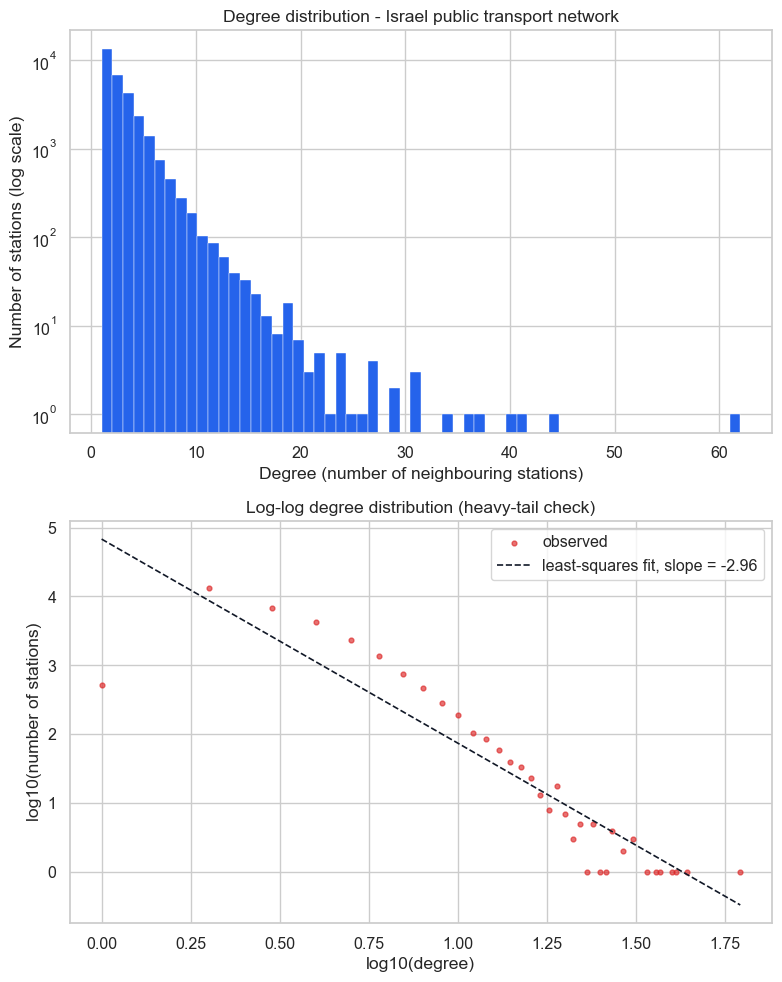

degree range: 1 to 62, mean 3.40, median 3
stations with degree <= 2: 13,609 (44.7%)
log-log least-squares slope: -2.96


In [7]:
# --- Degree distribution: histogram + log-log view -------------------------
deg_counts = pd.Series(degrees).value_counts().sort_index()
deg_counts = deg_counts[deg_counts.index > 0]

deg_table = pd.DataFrame({'degree': deg_counts.index.astype(int),
                          'num_stations': deg_counts.to_numpy().astype(int)})
deg_table['share'] = (deg_table['num_stations'] / len(degrees)).round(5)
deg_table.to_csv(TABLES / 'degree_distribution.csv', index=False, encoding='utf-8-sig')

x = np.log10(deg_table['degree'].to_numpy(dtype=float))
y = np.log10(deg_table['num_stations'].to_numpy(dtype=float))
slope, intercept = np.polyfit(x, y, 1)

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].hist(degrees, bins=DEG_HIST_BINS, color='#2563eb', edgecolor='white', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_xlabel('Degree (number of neighbouring stations)')
axes[0].set_ylabel('Number of stations (log scale)')
axes[0].set_title('Degree distribution - Israel public transport network')

axes[1].scatter(x, y, s=12, color='#dc2626', alpha=0.65, label='observed')
axes[1].plot(x, slope * x + intercept, color='#111827', linewidth=1.2, linestyle='--',
             label=f'least-squares fit, slope = {slope:.2f}')
axes[1].set_xlabel('log10(degree)')
axes[1].set_ylabel('log10(number of stations)')
axes[1].set_title('Log-log degree distribution (heavy-tail check)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'degree_distribution.png', dpi=FIG_DPI)
plt.show()

print(f'degree range: {degrees.min()} to {degrees.max()}, mean {degrees.mean():.2f}, median {np.median(degrees):.0f}')
print(f'stations with degree <= 2: {(degrees <= 2).sum():,} ({(degrees <= 2).mean():.1%})')
print(f'log-log least-squares slope: {slope:.2f}')

## 8. Connected components

A connected component is a maximal set of stops where you can get from any one of them to the others through some sequence of segments. If the network were a single component, every stop in the country would be reachable from every other stop. But that isn't the case - there are a few small isolated clusters (usually local services that don't touch the national network at all in this data snapshot). The bar chart shows the largest components on a logarithmic y-axis, because the gap between the giant component and the rest spans four orders of magnitude and otherwise wouldn't be readable. The full list of component sizes is saved to `tables/component_sizes.csv`.

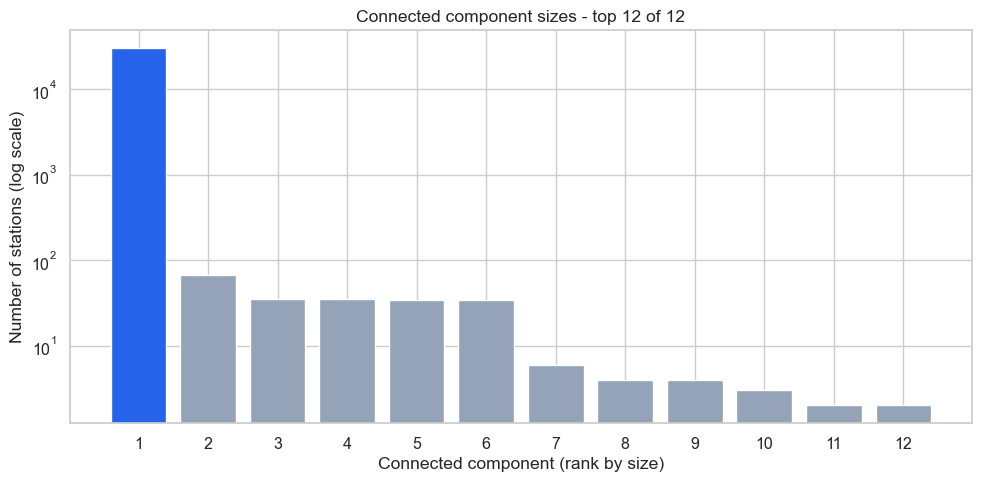

12 components; largest holds 30,237 stations (99.26%)


,component_rank,num_stations,share
0,1,30237,0.992581
1,2,67,0.002199
2,3,35,0.001149
3,4,35,0.001149
4,5,34,0.001116
5,6,34,0.001116
6,7,6,0.000197
7,8,4,0.000131
8,9,4,0.000131
9,10,3,0.000098


In [8]:
# --- Connected component sizes --------------------------------------------
comp_table = pd.DataFrame({'component_rank': range(1, len(component_sizes) + 1),
                           'num_stations': component_sizes})
comp_table['share'] = (comp_table['num_stations'] / G.number_of_nodes()).round(6)
comp_table.to_csv(TABLES / 'component_sizes.csv', index=False, encoding='utf-8-sig')

top_components = component_sizes[:TOP_N]
bar_colors = ['#2563eb' if i == 0 else '#94a3b8' for i in range(len(top_components))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(top_components) + 1), top_components, color=bar_colors)
ax.set_yscale('log')
ax.set_xticks(range(1, len(top_components) + 1))
ax.set_xlabel('Connected component (rank by size)')
ax.set_ylabel('Number of stations (log scale)')
ax.set_title(f'Connected component sizes - top {len(top_components)} of {len(component_sizes)}')
plt.tight_layout()
plt.savefig(FIGURES / 'components_summary_bar.png', dpi=FIG_DPI)
plt.show()

print(f'{len(component_sizes)} components; largest holds '
      f"{largest:,} stations ({largest / G.number_of_nodes():.2%})")
comp_table.head(TOP_N)

## 9. Articulation points and bridges

These are the structural single points of failure, and the reason this notebook matters to the project's robustness question.

* An articulation point is a stop whose removal splits its component into two or more parts. Passengers on one side lose all connectivity to the other side, not just a slower route.
* A bridge is a segment with the same property - the only physical connection between two parts of the network.

Both tables are exported in full, enriched with the stop name, coordinates, region and degree (for articulation points) or the endpoint names and trip frequency (for bridges), so later notebooks can cross-reference them. Sorting the bridges by trip frequency immediately reveals the single-connection segments carrying the largest service volume - the highest-impact bridge edges.

In [9]:
# --- Export cut vertices and cut edges -------------------------------------
ap_df = pd.DataFrame([{
    'stop_id': n,
    'stop_name': G.nodes[n]['stop_name'],
    'lat': G.nodes[n]['lat'],
    'lon': G.nodes[n]['lon'],
    'region': G.nodes[n]['region'],
    'metro': G.nodes[n]['metro'],
    'degree': G.degree(n),
} for n in ap])
ap_df = ap_df.sort_values('degree', ascending=False).reset_index(drop=True)
ap_df.to_csv(TABLES / 'articulation_points.csv', index=False, encoding='utf-8-sig')

br_df = pd.DataFrame([{
    'from_stop': u,
    'to_stop': v,
    'from_name': G.nodes[u]['stop_name'],
    'to_name': G.nodes[v]['stop_name'],
    'trip_frequency': int(G[u][v].get('weight', 1)),
} for u, v in br])
br_df = br_df.sort_values('trip_frequency', ascending=False).reset_index(drop=True)
br_df.to_csv(TABLES / 'bridges.csv', index=False, encoding='utf-8-sig')

print(f'articulation points : {len(ap_df):,} '
      f"({len(ap_df) / G.number_of_nodes():.2%} of all stations)")
print(f'bridges             : {len(br_df):,} '
      f"({len(br_df) / G.number_of_edges():.2%} of all undirected edges)")
print('\nHighest-traffic bridges:')
display(br_df.head(TOP_N))
print('Highest-degree articulation points:')
ap_df.head(TOP_N)

articulation points : 900 (2.95% of all stations)
bridges             : 971 (1.88% of all undirected edges)

Highest-traffic bridges:


,from_stop,to_stop,from_name,to_name,trip_frequency
0,44793,44795,אוניברסיטת חיפה,טכניון מרכז,2402
1,44795,44798,טכניון מרכז,מרכזית המפרץ,2402
2,23299,23298,ת. רכבת קרית אריה,ת. רכבת קרית אריה,1809
3,11448,48932,מסוף חומת שמואל/אליהו קורן,תחנה תפעולית/היציאה מחניון חומת שמואל,1672
4,10532,48933,רב החובל/אדם,תחנה תפעולית/חניון תלפיות מזרח,1575
5,49466,10576,מסוף הר נוף/כנפי נשרים,מסוף הר נוף/בית הדפוס,1306
6,49109,49149,יהודית,שאול המלך,1218
7,49145,49146,ביאליק,בן גוריון,1218
8,49093,49150,ארלוזורוב,אבא הלל,1218
9,49149,49093,שאול המלך,ארלוזורוב,1218


Highest-degree articulation points:


,stop_id,stop_name,lat,lon,region,metro,degree
0,41133,מחלף חמד,31.801002,35.124540,Jerusalem,Jerusalem,62
1,9048,בן גוריון/שערי ירושלים,31.791535,35.196465,Jerusalem,Jerusalem,41
2,10775,גשר המיתרים/שד' הרצל,31.787162,35.199533,Jerusalem,Jerusalem,37
3,12975,מחלף לה גווארדייה,32.059454,34.786354,Center,Tel Aviv,34
4,13246,בית ספר הולץ/חיל השריון,32.046238,34.783261,Center,Tel Aviv,31
5,13322,המסגר/הרכב,32.063660,34.785580,Center,Tel Aviv,27
6,9553,גשר המיתרים/שד' הרצל,31.787322,35.199369,Jerusalem,Jerusalem,22
7,13356,דרך קיבוץ גלויות/כביש 1,32.046861,34.784605,Center,Tel Aviv,20
8,27623,מרכז רפואי סורוקה/אוניברסיטת בן גוריון,31.259220,34.798363,South,Beer Sheva,20
9,14355,מחלף מורשה,32.123726,34.854708,Center,Tel Aviv,20


## 10. Which stops are the most important articulation points?

Not all articulation points are equally important. A degree-2 articulation point cuts off a dead-end branch of a few stops; a degree-30 articulation point is a hub whose loss would isolate a whole sub-network. The horizontal bar chart below ranks the top articulation points by degree, using the real Hebrew stop names (displayed correctly thanks to the bidi patch installed in section 3). This is the short list that the later robustness notebooks should focus on.

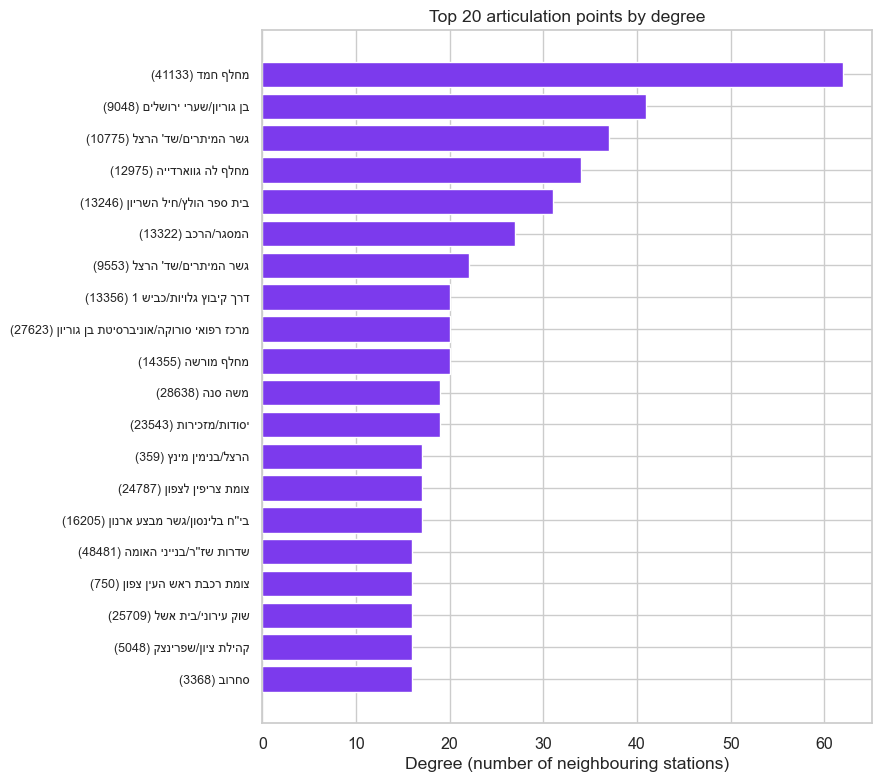

In [10]:
# --- Top articulation points by degree -------------------------------------
top_ap = ap_df.head(TOP_N).iloc[::-1]   # reversed so the largest ends up on top
labels = [f'{name} ({sid})' for name, sid in zip(top_ap['stop_name'], top_ap['stop_id'])]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(range(len(top_ap)), top_ap['degree'].to_numpy(), color='#7c3aed')
ax.set_yticks(range(len(top_ap)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Degree (number of neighbouring stations)')
ax.set_title(f'Top {len(top_ap)} articulation points by degree')
plt.tight_layout()
plt.savefig(FIGURES / 'top_articulation_points.png', dpi=FIG_DPI)
plt.show()

## 11. Geographic overview of the network

A scatter of every stop by its real longitude / latitude, with color and size set by degree, gives an immediate sense of where the network is dense (the Tel Aviv - Haifa coastal strip and Jerusalem) and where it thins out (the Negev). This is a plain lat/lon scatter, not a projected map, so we set the aspect ratio to `1 / cos(mean latitude)` to keep the shape of the country roughly correct instead of stretched sideways.

The coordinate filtering here is a deliberate fix to the original script, which used `if d.get("lat") and d.get("lon")`. That check evaluates as falsy for a coordinate whose value is exactly `0.0`, and worse, evaluates as truthy for `NaN`, so missing coordinates would have been plotted. Instead we check explicitly for a value that is present and finite.

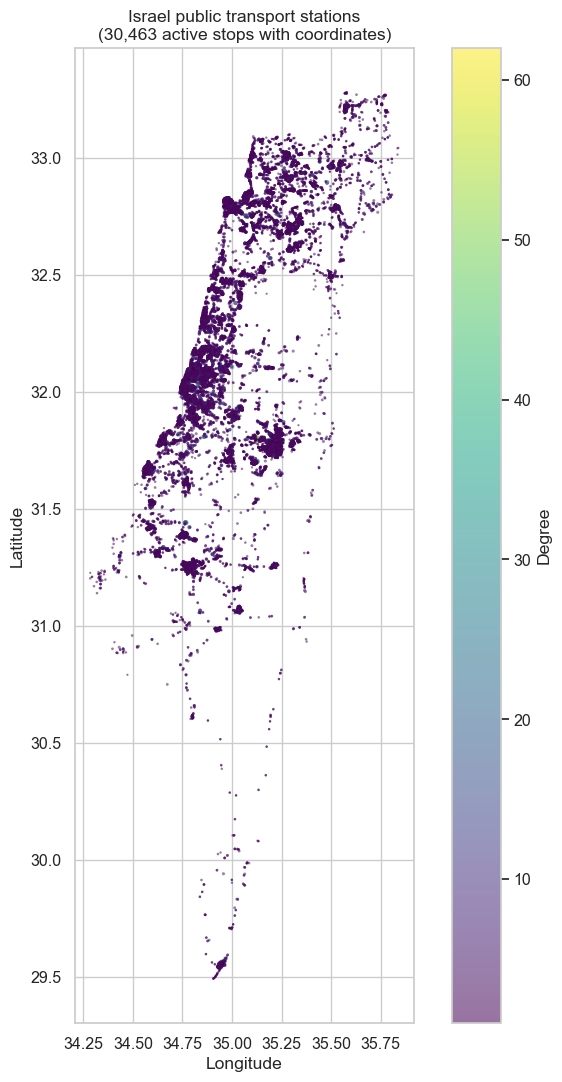

stations with coordinates: 30,463 of 30,463


In [11]:
# --- Network overview map (lat/lon scatter) --------------------------------
def has_coords(data):
    """True only when both coordinates are present and finite (0.0 included)."""
    lat, lon = data.get('lat'), data.get('lon')
    return lat is not None and lon is not None and np.isfinite(lat) and np.isfinite(lon)

coord_nodes = [(n, d) for n, d in G.nodes(data=True) if has_coords(d)]
if not coord_nodes:
    raise ValueError('No station carries usable coordinates - check nodes.csv from notebook 02.')

lats = [d['lat'] for _, d in coord_nodes]
lons = [d['lon'] for _, d in coord_nodes]
degs = [G.degree(n) for n, _ in coord_nodes]
max_deg = max(degs)
sizes = [2 + 30 * (d / max_deg) for d in degs]

fig, ax = plt.subplots(figsize=(8, 11))
sc = ax.scatter(lons, lats, c=degs, s=sizes, cmap='viridis', alpha=MAP_ALPHA, linewidths=0)
plt.colorbar(sc, ax=ax, label='Degree')
ax.set_aspect(1 / np.cos(np.deg2rad(float(np.mean(lats)))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Israel public transport stations\n'
             f'({len(coord_nodes):,} active stops with coordinates)')
plt.tight_layout()
plt.savefig(FIGURES / 'network_overview_map.png', dpi=FIG_DPI)
plt.show()

print(f'stations with coordinates: {len(coord_nodes):,} of {G.number_of_nodes():,}')

## 12. Stops by region

Finally, a simple count of the active stops per administrative region, which turns the geography above into numbers and serves as a useful sanity check that the region attribute survived the join in notebook 02. The bar colors are generated from a seaborn palette whose size is derived from the number of regions that actually exist - the original script hard-coded four colors, which would have caused silent cycling or a shortage of colors if the set of regions changed. The region names are in Hebrew and displayed through the bidi patch.

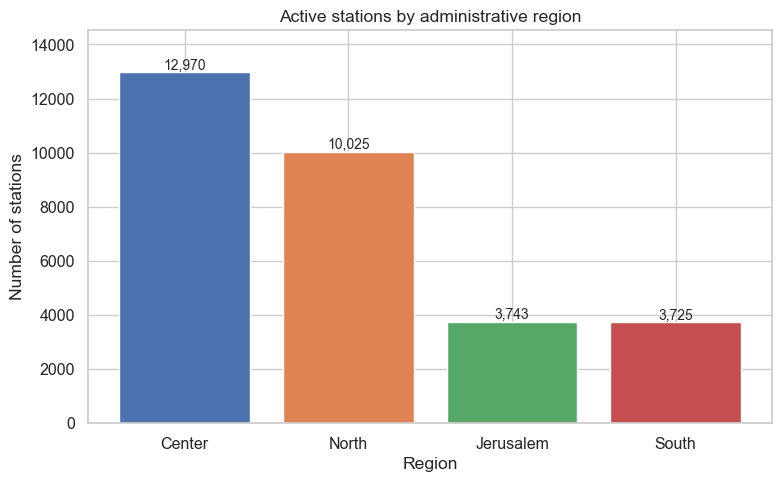

,region,num_stations,share
0,Center,12970,0.4258
1,North,10025,0.3291
2,Jerusalem,3743,0.1229
3,South,3725,0.1223


In [12]:
# --- Stations per region ---------------------------------------------------
region_counts = (pd.Series([G.nodes[n]['region'] or 'Unknown' for n in G.nodes()])
                 .value_counts())
region_table = region_counts.rename_axis('region').reset_index(name='num_stations')
region_table['share'] = (region_table['num_stations'] / G.number_of_nodes()).round(4)
region_table.to_csv(TABLES / 'stops_by_region.csv', index=False, encoding='utf-8-sig')

palette = sns.color_palette('deep', len(region_counts))
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(r) for r in region_counts.index], region_counts.to_numpy(), color=palette)
ax.set_xlabel('Region')
ax.set_ylabel('Number of stations')
ax.set_title('Active stations by administrative region')
for bar, val in zip(bars, region_counts.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.margins(y=0.12)
plt.tight_layout()
plt.savefig(FIGURES / 'stops_by_region.png', dpi=FIG_DPI)
plt.show()

region_table

## Conclusions

* The network is large and unusually sparse. About 30,463 active stops and 51,772 undirected segments give a density of around 0.0001 and an average degree of about 3.4 - a typical stop touches only three or four other stops. This is normal for a spatial transport network: geography, not popularity, is what limits who can be a neighbor.
* It's really one network. There are about 12 connected components, but the largest holds about 99.3% of all stops; the rest are tiny isolated clusters. So any claim about robustness in the following notebooks concerns the giant component, and "the network split" has to mean something stronger than "a few stops dropped out".
* The degree distribution is heavy-tailed, but don't overstate the claim. Most stops sit at degree 2 (a stop on a line), while a small number of transfer hubs reach dozens of neighbors. The log-log plot is roughly linear over most of the range, which is consistent with scale-free-like behavior - but the least-squares slope printed above is a descriptive fit, not a validated power-law estimator, and the tail is short. We report this as "heavy-tailed", not as "scale-free".
* Single points of failure do exist, but they are a small minority. About 900 articulation points (roughly 3% of the stops) and 971 bridges (less than 2% of the edges) are structural single points of failure. Two honest caveats: many of them are low-degree dead-end branches whose loss cuts off only a handful of stops - which is why section 10 ranks them by degree; and this is a purely topological view of failure - it ignores how many passengers actually use a segment, which is exactly what the centrality and robustness notebooks add later.
* The network is mostly bidirectional. The directed graph has only slightly more edges than the undirected projection, and the largest strongly connected component covers most of the network, meaning that for the overwhelming majority of stop pairs there's a return path. One-way segments are the exception.
* Geography dominates. Stops are concentrated mostly in the Center district and along the coastal metropolitan strip; the southern periphery is sparse. This is the structural backdrop against which the socioeconomic findings in the following notebooks should be read.